# Truncation Under Synthetic Control: What Top-k, Top-p, and Min-p Actually Remove

**A research note on decoding operators measured against ground truth.** On a real language model, nobody knows what a truncation operator removed — the true distribution is unavailable, so the cut can only be described, never scored. This study builds distributions whose tails are known by construction, so that what an operator *should* remove is computable in closed form and can be compared against what it *does* remove.

---

## Abstract

This artifact measures the three standard truncation operators against synthetic distributions with analytically known structure, on CPU, fully reproducible. **What/how:** Zipf and mixture distributions over a 49,152-symbol alphabet are constructed with a designated "signal" head and a "noise" tail of exactly known mass; top-k, top-p (nucleus), and min-p are then applied and scored on four axes — mass retained, symbols retained, noise removed, and `D_KL(p′‖p)` — with the ideal cut computable exactly. A tail-heaviness sweep varies the Zipf exponent to find where each operator's fixed hyperparameter stops matching the distribution it meets. **What it shows:** which operator's parameter is stable across distribution shapes and which one silently changes meaning, quantified as the gap between the cut taken and the cut ground truth demanded. **What it does not claim:** synthetic distributions are not language-model distributions; the real-logit study that follows tests whether these orderings survive contact with measured data. Correctness rests on the numbers the cells produce.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| Fan et al. (2018) | *Hierarchical Neural Story Generation*, arXiv:1805.04833 | Introduces top-k sampling | We measure what a fixed `k` costs when the distribution's width changes underneath it |
| Holtzman et al. (2020) | *The Curious Case of Neural Text Degeneration*, arXiv:1904.09751 | Introduces nucleus (top-p); the "unreliable tail" argument | They validate on generated text; we score against a tail whose mass is known exactly |
| Meister et al. (2023) | *Locally Typical Sampling*, arXiv:2202.00666 | Truncation by information content rather than rank or mass | Provides the third design axis our operators are compared on |
| Nguyen et al. (2024) | *Min-p Sampling*, arXiv:2407.01082 | Relative threshold `p_min = α · max(p)`, adaptive to confidence | We test the adaptivity claim against a controlled sweep of distribution shape |
| Hewitt et al. (2022) | *Truncation Sampling as Language Model Desmoothing*, arXiv:2210.15191 | Frames truncation as removing the smoothing a model was trained with | Motivates why an oracle head/tail split is the right synthetic control |
| Zipf (1949) / Piantadosi (2014) | *Zipf's law in natural language*, Psychon. Bull. Rev. | Token frequency follows a power law with exponent near 1 | The generative model for our synthetic tails, with the exponent as the swept knob |
| Cover & Thomas (2006) | *Elements of Information Theory* | `D_KL`, and the cost of renormalizing a truncated distribution | The scoring metric, applied to a cut whose ideal is known |

**The differentiator.** Every truncation paper evaluates on real models, where the correct cut is undefined and quality must be judged by human raters or a proxy metric. Inverting that — constructing the distribution first, so the correct cut is a number — turns "does this operator work" into an arithmetic question. The tradeoff is stated up front: synthetic distributions are a controlled instrument, not a claim about language.

## The measurement object and metrics

**The construction.** A synthetic distribution over `V = 49,152` symbols is built in two designated parts:

- **Signal head:** `n_sig` symbols carrying total mass `m_sig`, shaped by a Zipf profile `w_i ∝ i^{−s_head}`.
- **Noise tail:** the remaining `V − n_sig` symbols sharing mass `1 − m_sig` on a Zipf continuation with its own exponent `s_tail`.

Because the split is *designed*, the ideal cut is defined: **retain the head, discard the tail**. Every operator is scored against that oracle. No language model is involved and no judgement of text quality is required.

**The three operators.** Each maps `p → p′` by zeroing coordinates and renormalizing, `p′_i = p_i · 1[i ∈ S] / Σ_{j∈S} p_j`. They differ only in how the support `S` is chosen:

$$\textbf{top-k:}\quad S = \{\text{the } k \text{ largest } p_i\} \qquad \text{a fixed \emph{count}; shape is ignored}$$

$$\textbf{top-p:}\quad S = \text{smallest prefix of sorted } p \text{ with } \textstyle\sum_{i\in S} p_i \ge p_{\text{nuc}} \qquad \text{a fixed \emph{mass}; count adapts}$$

$$\textbf{min-p:}\quad S = \{\, i : p_i \ge \alpha \cdot \max_j p_j \,\} \qquad \text{a fixed \emph{relative height}; mass and count both adapt}$$

The design intents differ accordingly: top-k fixes the branching factor, top-p fixes the coverage, min-p fixes the confidence ratio between the best candidate and the worst acceptable one. Which of those three invariants is the useful one is exactly what a controlled sweep can answer.

**The scores.** For an operator producing support `S`:

- **`mass_kept` = `Σ_{i∈S} p_i`** — coverage of the original distribution.
- **`n_kept` = `|S|`** — the surviving branching factor.
- **`noise_removed`** — fraction of designed *tail* mass excluded; the true-positive rate against the oracle.
- **`signal_lost`** — fraction of designed *head* mass excluded; the false-positive rate.
- **`D_KL(p′‖p)`** — the distortion introduced by renormalizing, derived in closed form two cells below.
- **`H(p′)`, `exp(H(p′))`** — entropy and effective branching factor after the cut, comparable to the widths measured in the earlier studies.

## Hypothesis board (decided before measurement)

| # | Claim (falsifiable) | Predicted |
|---|---|---|
| C1 | For any truncation, `D_KL(p′‖p) = −log(mass_kept)` exactly | agreement ≤ 1e-12 in float64 |
| C2 | On a fixed distribution, all three operators can be tuned to the oracle cut | each achieves `noise_removed > 0.95` with `signal_lost < 0.05` at some setting |
| C3 | A fixed `k` fails when distribution width changes | across the Zipf exponent sweep, top-k's `noise_removed` varies by > 0.4 at constant `k` |
| C4 | Top-p's *count* varies far more than its mass, by construction | `n_kept` spans > 10× across the same sweep while `mass_kept` stays within 0.01 |
| C5 | Min-p adapts best to shape changes | min-p's `noise_removed` spread across the sweep is the smallest of the three |
| C6 | On a flat (high-entropy) distribution, top-p degenerates toward keeping nearly everything | at `p_nuc = 0.9` on the flattest case, `n_kept` > 1,000 |

**How a verdict is won.** C1 is an exact-identity claim judged at float64 precision. C2 is an existence claim over the swept hyperparameter grid. C3, C4, C5 are spread claims: each operator's score range across the Zipf sweep against a pre-stated threshold. C6 is a single-point prediction on the designated flattest distribution.

**Pre-committed honesty note.** These distributions are constructed, not observed. A Zipf head with a designed tail is a caricature of a language model's output — real next-token distributions are context-dependent, vary enormously position to position (the earlier study measured `k90` ranging 1 to 12,097 inside one document), and possess no ground-truth head/tail split. The synthetic control buys exact scoring at the cost of external validity, and the study that follows is the one that tests transfer.

## Protocol & constraints

- **No model.** This study loads no weights; everything is constructed with `torch` and a fixed seed. It is the only model-free study in the repository, which is what makes its ground truth exact.
- **Alphabet:** `V = 49,152`, matching SmolLM2's vocabulary so widths are directly comparable to the measured studies.
- **Precision:** float64 throughout. The KL claim is about exactness, and float32 would park the residual at the eps floor rather than testing anything; a float32 mirror is reported once, for contrast.
- **Seed:** fixed for the symbol shuffle; every table is reproducible bit-for-bit.
- **Operators implemented by hand.** No library sampler is used, so the semantics measured are the semantics written in the cell.
- **Notation:** `p` is the constructed distribution (model-side), `p′` the truncated and renormalized one, `is_sig` the oracle mask marking the designed head. Imports needed across the study: `torch`, `numpy`, `matplotlib.pyplot`, `math`.

## The construction rig

**Why:** every claim here depends on a distribution whose head and tail are known by design rather than inferred. One builder returning both the distribution and its oracle mask makes every later score a lookup instead of an estimate.

**The shape of the code:**

```
make_dist(V, n_sig, m_sig, s_head, s_tail, seed) -> (p, is_sig)
    ranks_head = 1 .. n_sig                     # 1-indexed, Zipf needs i >= 1
    ranks_tail = 1 .. (V - n_sig)
    w_head = ranks_head ** (-s_head)            # unnormalized Zipf weights
    w_tail = ranks_tail ** (-s_tail)
    w_head *= m_sig       / w_head.sum()        # scale the block to its designed mass
    w_tail *= (1 - m_sig) / w_tail.sum()
    p_sorted  = concat(w_head, w_tail)          # descending-ish, head block first
    is_sorted = concat(ones(n_sig), zeros(V-n_sig)).bool()
    perm = randperm(V, generator=Generator().manual_seed(seed))
    return p_sorted[perm].double(), is_sorted[perm]

describe(name, p, is_sig) -> dict
    top1   = p.max()
    H      = -(p * log(p.clamp_min(1e-300))).sum()
    srt    = sort(p, descending=True).values
    k90    = (cumsum(srt) < 0.90).sum() + 1
    checks : abs(p.sum() - 1) < 1e-12 ; p[is_sig].sum() ~= m_sig
    print one row: name, n_sig, m_sig, top1, H, exp(H), k90
```

**Design points worth stating.** The permutation matters: without it "the head" would be "the first `n_sig` indices" and an operator could trivially exploit index order. After shuffling, head membership is recoverable only from the probabilities, exactly as on real logits. Zipf weights need 1-indexed ranks — `0 ** (-s)` is infinite. The `clamp_min` inside the entropy guards `log(0)` on tail entries that underflow even in float64.

**The family to construct and reuse.** Three cases spanning the range measured on real logits:

| Case | `n_sig` | `m_sig` | `s_head` | `s_tail` | Intent |
|---|---|---|---|---|---|
| peaked | 5 | 0.95 | 1.5 | 1.0 | a syntactically pinned position |
| typical | 250 | 0.85 | 1.4 | 1.0 | tuned to the measured median (`exp(H) ≈ 67`, `k90 ≈ 222`) |
| flat | 5000 | 0.90 | 0.6 | 0.8 | an open, high-entropy position |

The typical case's parameters were chosen by a small grid search against the real-logit medians, not by taste: they land at `exp(H) ≈ 61` and `k90 ≈ 240` against the measured 66.6 and 222. That is the closest a two-block Zipf gets to a real position, and the residual gap is itself a statement about how crude the caricature is.

**What the run shows:** three distributions with known internals, their shape statistics printed alongside the real-logit medians from the earlier study, so the synthetic instrument can be checked for realism before anything is measured with it.

In [8]:
import torch, math

V = 49152


def make_dist(V, n_sig, m_sig, s_head, s_tail, seed=0):
   # 2-block Zipf a designed head/tail split, then suffled
    rh = torch.arange(1, n_sig + 1, dtype=torch.float64)        # 1-indexed: 0**(-s) is inf
    rt = torch.arange(1, V - n_sig + 1, dtype=torch.float64)
    wh = rh ** (-s_head)
    wt = rt ** (-s_tail)
    wh = wh * m_sig / wh.sum()                                   # scale each block to its mass
    wt = wt * (1.0 - m_sig) / wt.sum()
    p_sorted  = torch.cat([wh, wt])
    is_sorted = torch.cat([torch.ones(n_sig), torch.zeros(V - n_sig)]).bool()
    perm = torch.randperm(V, generator=torch.Generator().manual_seed(seed))
    return p_sorted[perm].double(), is_sorted[perm]

def describe(name, p, is_sig, m_sig):
    H   = -(p * p.clamp_min(1e-300).log()).sum()                 # clamp: tail underflows
    srt = p.sort(descending=True).values
    k90 = int((srt.cumsum(0) < 0.90).sum()) + 1
    assert abs(float(p.sum()) - 1.0) < 1e-12,             f"{name}: p does not sum to 1"
    assert abs(float(p[is_sig].sum()) - m_sig) < 1e-12,   f"{name}: head mass wrong"
    print(f"{name:8s} {int(is_sig.sum()):6d} {m_sig:6.2f} {p.max():8.4f} "
          f"{H:7.3f} {H.exp():9.1f} {k90:6d} {abs(p.sum()-1):10.2e}")
    return {"H": float(H), "expH": float(H.exp()), "k90": k90, "top1": float(p.max())}

CASES = {
    "peaked":  dict(n_sig=5,    m_sig=0.95, s_head=1.5, s_tail=1.0),
    "typical": dict(n_sig=250,  m_sig=0.85, s_head=1.4, s_tail=1.0),
    "flat":    dict(n_sig=5000, m_sig=0.90, s_head=0.6, s_tail=0.8),
}

D, STATS = {}, {}
print(f"{'case':8s} {'n_sig':>6} {'m_sig':>6} {'top1':>8} {'H':>7} {'exp(H)':>9} {'k90':>6} {'sum-1':>10}")
for nm, kw in CASES.items():
    p, s = make_dist(V, seed=0, **kw)
    D[nm] = (p, s)
    STATS[nm] = describe(nm, p, s, kw["m_sig"])

print(f"\nreal-logit medians measured earlier: exp(H) = 66.6, k90 = 222, top1 = 0.259")
print(f"synthetic 'typical':                 exp(H) = {STATS['typical']['expH']:.1f}, "
      f"k90 = {STATS['typical']['k90']}, top1 = {STATS['typical']['top1']:.3f}")
print(f"log V = {math.log(V):.4f} nats (uniform ceiling)")

case      n_sig  m_sig     top1       H    exp(H)    k90      sum-1
peaked        5   0.95   0.5396   1.740       5.7      4   1.11e-16
typical     250   0.85   0.3002   4.112      61.1    240   2.22e-16
flat       5000   0.90   0.0122   8.498    4907.4   4815   0.00e+00

real-logit medians measured earlier: exp(H) = 66.6, k90 = 222, top1 = 0.259
synthetic 'typical':                 exp(H) = 61.1, k90 = 240, top1 = 0.300
log V = 10.8027 nats (uniform ceiling)


## The three operators, written from their definitions

**Why:** the semantics under test must be the semantics in the cell. Library implementations differ in tie-breaking, in whether the boundary token of a nucleus is included, and in whether filtering happens before or after temperature — details that change the measured numbers. Writing them by hand fixes the contract.

**The shape of the code:**

```
keep_topk(p, k)   -> bool mask
    idx = topk(p, k).indices ; mask = zeros_like(p, bool) ; mask[idx] = True

keep_topp(p, p_nuc) -> bool mask
    srt, order = sort(p, descending=True)
    cum  = cumsum(srt, 0)
    n    = (cum < p_nuc).sum() + 1          # +1 INCLUDES the boundary token
    mask = zeros_like(p, bool) ; mask[order[:n]] = True

keep_minp(p, alpha) -> bool mask
    mask = p >= alpha * p.max()

renorm(p, mask) -> p_prime
    q = where(mask, p, 0) ; return q / q.sum()

evaluate(p, mask, is_sig) -> dict
    mass_kept     = p[mask].sum()
    n_kept        = mask.sum()
    signal_lost   = p[is_sig & ~mask].sum() / p[is_sig].sum()
    noise_removed = p[~is_sig & ~mask].sum() / p[~is_sig].sum()
    pp            = renorm(p, mask)
    kl            = (pp[mask] * log(pp[mask] / p[mask])).sum()
    Hp            = -(pp[mask] * log(pp[mask])).sum()
    guards: mask.any() ; abs(pp.sum() - 1) < 1e-12
    return {mass_kept, n_kept, signal_lost, noise_removed, kl, Hp, exp(Hp)}
```

**The boundary convention, stated because it is measurable.** `(cum < p_nuc).sum() + 1` includes the token that pushes the cumulative sum past the threshold. Excluding it would make `mass_kept < p_nuc` on every call, which is the opposite of what "nucleus of mass `p_nuc`" is meant to promise. The `+1` is the standard convention; naming it here means the later `mass_kept ≥ p_nuc` result is a check, not a coincidence.

**Two guards worth keeping.** An empty support makes `renorm` divide by zero — possible with an absurd `α`, so it is asserted rather than discovered. And `signal_lost` / `noise_removed` are *mass* fractions, not symbol counts; a rule that discards ten thousand tail symbols carrying 0.1% is doing almost nothing, and the mass-based definition says so.

**What the run shows:** the three operators applied at their conventional defaults (`k = 50`, `p_nuc = 0.9`, `α = 0.1`) to the typical case, side by side on all seven scores — the first direct comparison of what each default actually does to the same distribution.

In [13]:
def keep_topk(p, k):
    m = torch.zeros_like(p, dtype=torch.bool)
    m[p.topk(k).indices] = True
    return m

def keep_topp(p, p_nuc):
    srt, order = p.sort(descending=True)
    n = int((srt.cumsum(0) < p_nuc).sum()) + 1     # +1 includes the boundary token
    m = torch.zeros_like(p, dtype=torch.bool)
    m[order[:n]] = True
    return m

def keep_minp(p, alpha):
    return p >= alpha * p.max()

def renorm(p, m):
    q = torch.where(m, p, torch.zeros_like(p))
    return q / q.sum()

def evaluate(p, m, is_sig):
    assert bool(m.any()), "empty support"
    pp = renorm(p, m)
    assert abs(float(pp.sum()) - 1.0) < 1e-12
    Hp = float(-(pp[m] * pp[m].log()).sum())
    return {
        "mass_kept":        float(p[m].sum()),
        "n_kept":           int(m.sum()),
        "signal_lost":      float(p[is_sig & ~m].sum() / p[is_sig].sum()),
        "noise_removed":    float(p[~is_sig & ~m].sum() / p[~is_sig].sum()),
        "kl":               float((pp[m] * (pp[m] / p[m]).log()).sum()),
        "H":                Hp,
        "expH":             math.exp(Hp),
    }

OPS     = {"topk": keep_topk, "topp": keep_topp, "minp": keep_minp}
DEFAULT = {"topk": 50, "topp": 0.9, "minp": 0.1}

p, s = D["typical"]
print("the three conventional defaults, same distribution ('typical')")
print(f"{'op':6s} {'param':>7} {'mass':>8} {'n_kept':>7} {'noise_rm':>9} "
      f"{'sig_lost':>9} {'KL':>9} {'exp(H)':>9}")
for nm, f in OPS.items():
    r = evaluate(p, f(p, DEFAULT[nm]), s)
    print(f"{nm:6s} {DEFAULT[nm]:>7} {r['mass_kept']:8.4f} {r['n_kept']:7d} "
          f"{r['noise_removed']:9.4f} {r['signal_lost']:9.4f} {r['kl']:9.6f} {r['expH']:9.1f}")

print(f"\noracle: keep the {int(s.sum())} designed head symbols "
      f"(mass {float(p[s].sum()):.4f}) -> noise_removed 1.0, signal_lost 0.0")

the three conventional defaults, same distribution ('typical')
op       param     mass  n_kept  noise_rm  sig_lost        KL    exp(H)
topk        50   0.8007      50    0.7611    0.1001  0.222242      13.1
topp       0.9   0.9002     240    0.5857    0.0141  0.105158      24.4
minp       0.1   0.5531       5    1.0000    0.3492  0.592138       3.6

oracle: keep the 250 designed head symbols (mass 0.8500) -> noise_removed 1.0, signal_lost 0.0


## The renormalization identity

**Why:** truncation is not a soft reweighting; it deletes mass and rescales what remains. The distortion that introduces has a closed form worth verifying, because it explains a widespread misreading of KL as a quality score.

**The derivation.** Let `M = Σ_{i∈S} p_i` be the retained mass. On `S`, `p′_i = p_i / M`; elsewhere `p′_i = 0`, and those terms drop out of the sum (`0 · log 0 = 0`). So

$$D_{\mathrm{KL}}(p' \,\|\, p) = \sum_{i \in S} \frac{p_i}{M} \log \frac{p_i / M}{p_i} = \log\frac{1}{M} \cdot \frac{1}{M}\sum_{i \in S} p_i = -\log M$$

The result depends on **nothing but the retained mass**. Two operators keeping 90% of the mass are equally distorted by this measure even if one kept exactly the designed signal and the other kept exactly the designed noise. KL measures *how much* was cut, never *whether the right thing* was cut — the entire reason this study carries oracle-based scores alongside it.

Note the direction as well: `D_KL(p‖p′)` is infinite for any truncation, since the original assigns mass where the truncated assigns zero and the `log(p_i/0)` terms diverge. The finite, usable direction is `D_KL(p′‖p)`, the one derived above.

**The shape of the code:**

```
settings = [("topk", k) for k in (10, 50, 200, 1000)]
         + [("topp", p) for p in (0.5, 0.9, 0.99)]
         + [("minp", a) for a in (0.5, 0.1, 0.01)]

for each setting on the typical case:
    mask = the matching keep_* call
    r    = evaluate(p, mask, is_sig)
    identity = -log(r.mass_kept)
    residual = abs(r.kl - identity)
    print: op, param, mass_kept, kl, -log(M), residual

report max residual in float64
repeat once with p.float() to show the float32 residual for contrast
also verify the infinite direction: D_KL(p || p') has a zero denominator -> report count of
   coordinates where p > 0 and p' == 0 (the reason it diverges), not the value
```

**What the run shows:** whether the identity holds to machine precision, how much of it survives float32 — the same precision question the first study asked of softmax, now asked at the decoding stage — and an explicit count of the coordinates that make the reverse direction infinite.


- top-k — keep the k highest-probability tokens, drop everything else. Fixed count. k=50 always keeps exactly 50 candidates, whether the model is certain or clueless. Oldest of the three (Fan et al. 2018).

- top-p (nucleus sampling) — sort by probability, keep adding tokens until you've accumulated p_nuc of the mass. Fixed mass. p_nuc=0.9 keeps 90% of the probability, however many tokens that takes — 1 token when confident, 12,000 when not. Holtzman et al. 2020.

- min-p — keep every token at least α times as likely as the best token. Fixed relative height. α=0.1 keeps anything within 10× of the top candidate. Nguyen et al. 2024.

In [19]:
GRID_ALL = ([("topk", k) for k in (10, 50, 200, 1000)]
          + [("topp", v) for v in (0.5, 0.9, 0.99)]
          + [("minp", a) for a in (0.5, 0.1, 0.01)])

p, s = D["typical"]
print(f"{'op':6s} {'param':>7} {'mass_kept':>10} {'KL':>10} {'-log(M)':>10} {'residual':>11}")
worst64 = 0.0
for nm, v in GRID_ALL:
    r = evaluate(p, OPS[nm](p, v), s)
    idn = -math.log(r["mass_kept"])
    res = abs(r["kl"] - idn); worst64 = max(worst64, res)
    print(f"{nm:6s} {v:>7} {r['mass_kept']:10.6f} {r['kl']:10.6f} {idn:10.6f} {res:11.2e}")
print(f"\nmax residual (float64): {worst64:.2e}")

p32 = p.float()
w32 = 0.0
for nm, v in GRID_ALL:
    m32 = OPS[nm](p32, v)
    pp32 = renorm(p32, m32)
    kl32 = float((pp32[m32] * (pp32[m32] / p32[m32]).log()).sum())
    M32  = float(p32[m32].sum())
    w32  = max(w32, abs(kl32 + math.log(M32)))
print(f"max residual (float32): {w32:.2e}   (eps = {torch.finfo(torch.float32).eps:.2e})")

m = OPS["topp"](p, 0.9)
print(f"\nreverse direction D_KL(p||p'): {int((~m).sum())} of {V} coordinates have "
      f"p > 0 but p' = 0  ->  log(p/0) diverges, so the usable direction is D_KL(p'||p)")


op       param  mass_kept         KL    -log(M)    residual
topk        10   0.640649   0.445274   0.445274    0.00e+00
topk        50   0.800722   0.222242   0.222242    1.94e-16
topk       200   0.890710   0.115736   0.115736    1.39e-16
topk      1000   0.944920   0.056655   0.056655    3.47e-17
topp       0.5   0.521601   0.650853   0.650853    2.22e-16
topp       0.9   0.900182   0.105158   0.105158    2.78e-17
topp      0.99   0.990001   0.010050   0.010050    2.43e-17
minp       0.5   0.300234   1.203194   1.203194    0.00e+00
minp       0.1   0.553143   0.592138   0.592138    3.33e-16
minp      0.01   0.757521   0.277704   0.277704    1.11e-16

max residual (float64): 3.33e-16
max residual (float32): 1.54e-07   (eps = 1.19e-07)

reverse direction D_KL(p||p'): 48912 of 49152 coordinates have p > 0 but p' = 0  ->  log(p/0) diverges, so the usable direction is D_KL(p'||p)


## Sweeping the hyperparameter against the oracle

**Why:** each operator has one knob, and the question is whether any setting of it recovers the designed head. This is the existence claim: on a *fixed* distribution, can each operator be tuned to the oracle cut?

**The trade being traced.** Every operator faces the same tension. Cutting harder removes noise (`noise_removed → 1`) but eventually eats signal (`signal_lost → 1`). The oracle point is the setting maximizing `noise_removed − signal_lost`; for a perfectly separable design that reaches exactly `1.0`. The distance from 1.0 measures how *separable* the constructed distribution is — how cleanly a rank-, mass-, or height-based rule can distinguish head from tail. That number is a property of the distribution, not of the operator, which is why all three are read against it.

**The shape of the code:**

```
GRID = {
  "topk": [1, 5, 10, 20, 50, 100, 200, 500, 1000],
  "topp": [0.5, 0.7, 0.8, 0.9, 0.95, 0.99],
  "minp": [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.001],
}
DEFAULT = {"topk": 50, "topp": 0.9, "minp": 0.1}

for op, values in GRID.items():
    for v in values:
        r = evaluate(p_typical, keep_<op>(p_typical, v), is_sig_typical)
        store (op, v, r)
    best = argmax over v of (noise_removed - signal_lost)
    print: op, best v, its noise_removed / signal_lost / n_kept / mass_kept,
           and whether it clears C2 (noise_removed > 0.95 and signal_lost < 0.05)

figure: one axes, x = signal_lost, y = noise_removed, one line per operator
        (points ordered by increasing aggressiveness), each operator's DEFAULT
        marked with a large marker, and the ideal corner (0, 1) annotated
```

**Reading the figure.** The upper-left corner is perfect: all noise gone, no signal lost. A line that hugs that corner is an operator whose rule matches the structure of the distribution; a line that bows toward the diagonal is one that cannot separate head from tail no matter how it is tuned. Where each default marker sits relative to its own line's best point is the practical question — a good operator badly defaulted is a different problem from a bad operator.

**What the run shows:** whether each operator's design admits a setting that finds the designed head, and how far the conventional defaults sit from that optimum.

topk   best     20: score 0.6902 | noise_rm 0.8681 sig_lost 0.1779 n_kept    20 | C2 FAIL
topp   best    0.7: score 0.6701 | noise_rm 0.8681 sig_lost 0.1981 n_kept    17 | C2 FAIL
minp   best   0.05: score 0.7219 | noise_rm 1.0000 sig_lost 0.2781 n_kept     8 | C2 FAIL


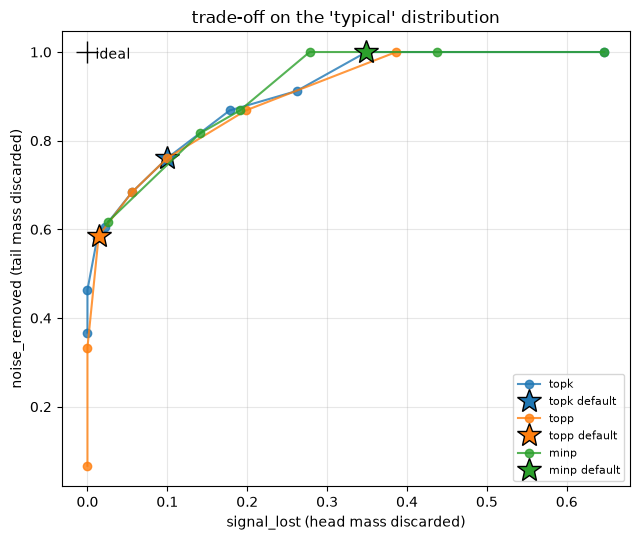

In [20]:
import matplotlib.pyplot as plt

GRID = {"topk": [1, 5, 10, 20, 50, 100, 200, 250, 500, 1000],
        "topp": [0.5, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99],
        "minp": [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.001]}

curves = {}
for nm, vals in GRID.items():
    curves[nm] = [(v, evaluate(p, OPS[nm](p, v), s)) for v in vals]
    best_v, best_r = max(curves[nm], key = lambda t: t[1]["noise_removed"] - t[1]["signal_lost"])
    ok = best_r["noise_removed"] > 0.95 and best_r["signal_lost"] < 0.05
    print(f"{nm:6s} best {str(best_v):>6}: score {best_r['noise_removed']-best_r['signal_lost']:.4f}"
          f" | noise_rm {best_r['noise_removed']:.4f} sig_lost {best_r['signal_lost']:.4f}"
          f" n_kept {best_r['n_kept']:5d} | C2 {'PASS' if ok else 'FAIL'}")

plt.figure(figsize=(6.5, 5.5))
for nm, col in zip(GRID, ["tab:blue", "tab:orange", "tab:green"]):
    xs = [r["signal_lost"] for _, r in curves[nm]]
    ys = [r["noise_removed"] for _, r in curves[nm]]
    plt.plot(xs, ys, "o-", color=col, label=nm, alpha=0.8)
    rd = evaluate(p, OPS[nm](p, DEFAULT[nm]), s)
    plt.plot(rd["signal_lost"], rd["noise_removed"], "*", color=col, ms=18,
             markeredgecolor="k", label=f"{nm} default")
plt.plot(0, 1, "k+", ms=16); plt.annotate("ideal", (0.01, 0.985))
plt.xlabel("signal_lost (head mass discarded)"); plt.ylabel("noise_removed (tail mass discarded)")
plt.title("trade-off on the 'typical' distribution"); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close("all")

## Changing the distribution underneath a fixed setting

**Why:** the previous experiment tunes each operator to one distribution. In deployment the hyperparameter is fixed once and then meets a different distribution at every position — the earlier study measured `k90` ranging from 1 to 12,097 within a single document. The question that matters is therefore not "can it be tuned" but "does the tuning survive a change of shape".

**The sweep.** The Zipf exponent `s` controls tail heaviness: large `s` gives a steep, concentrated distribution, small `s` a flat one with a long fat tail. Sweeping `s` while holding every operator setting fixed reproduces exactly the deployment situation.

The three operators respond to shape differently *by construction*, and the predictions follow from the definitions rather than from intuition:

- **top-k** pins `n_kept` at `k` whatever the shape, so its retained *mass* must swing — on a peaked distribution `k = 50` keeps nearly everything, on a flat one a sliver.
- **top-p** pins `mass_kept` at `p_nuc`, so its *count* must swing instead. Whether that is the better failure mode is empirical, not definitional.
- **min-p** pins neither, thresholding relative to the peak. Its behavior under a shape change cannot be read off the definition, which is why it needs measuring.

**The shape of the code:**

```
S_SWEEP = [0.6, 0.8, 1.0, 1.2, 1.5, 2.0]        # Zipf exponent, flat -> steep
build one distribution per s with n_sig, m_sig held FIXED (only the shape moves):
    make_dist(V, n_sig=200, m_sig=0.90, s_head=s, s_tail=s, seed=0)

for each s, for each op at its DEFAULT:
    r = evaluate(...)  -> record mass_kept, n_kept, noise_removed, signal_lost, exp(H')

table 1: one block per operator, rows = s, columns = the five scores
table 2: per operator, min -> max spread of noise_removed and of n_kept
         verdicts: C3 (topk spread > 0.4), C4 (topp n_kept spread > 10x AND
         mass_kept range < 0.01), C5 (minp has the smallest noise_removed spread)
C6 check: on the flat case, topp at p_nuc = 0.9 -> n_kept > 1000 ?

figure, three panels sharing the x-axis (s):
    panel 1: noise_removed vs s, one line per operator  (stability of the guarantee)
    panel 2: n_kept vs s, log y-axis                    (how the branching factor moves)
    panel 3: mass_kept vs s                             (which line is flat by construction)
```

**What to watch.** Panel 3 should show top-p as a horizontal line — that is its definition, and seeing it flat is the sanity check on the rig. The interesting lines are the *other two* in that panel, and all three in panel 1: an operator whose `noise_removed` swings with `s` is an operator whose promise depends on a shape the caller does not control.

**What the run shows:** which operator's guarantee is stable across shape and which one's silently changes meaning — the deployment-relevant result of this study.



topk @ 50
    s     mass  n_kept  noise_rm  sig_lost    exp(H)
  0.6   0.4102      50    1.0000    0.5174      40.2
  0.8   0.5204      50    0.9743    0.3923      32.6
  1.0   0.6428      50    0.8168    0.2760      25.4
  1.2   0.7674      50    0.5348    0.1793      19.4
  1.5   0.9010      50    0.2230    0.0772      12.6
  2.0   0.9816      50    0.0392    0.0147       6.5

topp @ 0.9
    s     mass  n_kept  noise_rm  sig_lost    exp(H)
  0.6   0.9000    3553    0.6666    0.0000     257.0
  0.8   0.9000     761    0.6666    0.0000     160.5
  1.0   0.9003     275    0.6645    0.0000      83.3
  1.2   0.9002     174    0.3952    0.0477      38.2
  1.5   0.9010      50    0.2230    0.0772      12.6
  2.0   0.9072      10    0.1725    0.0787       4.3

minp @ 0.1
    s     mass  n_kept  noise_rm  sig_lost    exp(H)
  0.6   0.3943      46    1.0000    0.5361      37.2
  0.8   0.3531      17    1.0000    0.5846      13.0
  1.0   0.4081      10    1.0000    0.5199       7.3
  1.2   0.4

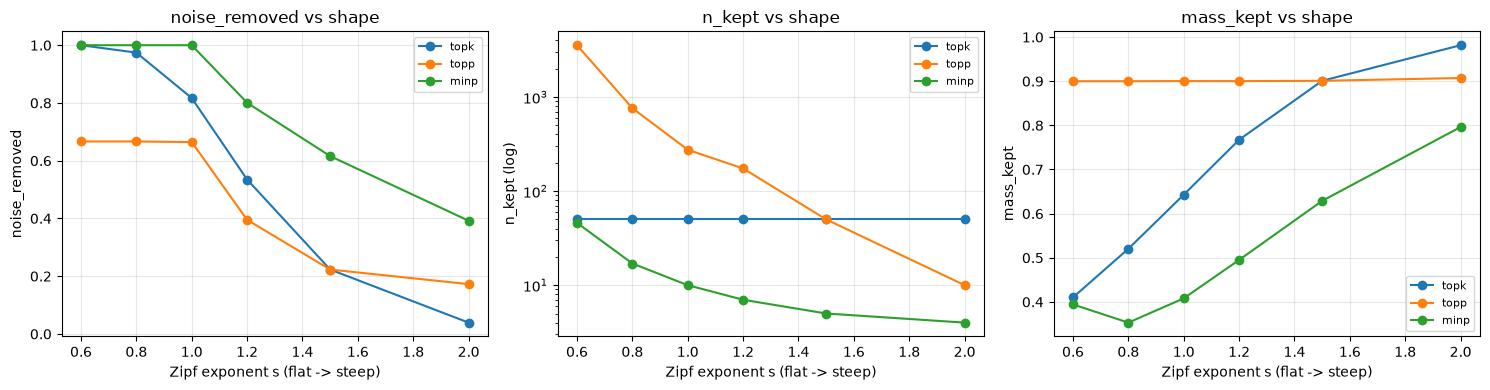

: 

In [ ]:
S_SWEEP = [0.6, 0.8, 1.0, 1.2, 1.5, 2.0]
sweep = {}
for sv in S_SWEEP:
    pv, sg = make_dist(V, n_sig=250, m_sig=0.85, s_head=sv, s_tail=sv, seed=0)
    sweep[sv] = {nm: evaluate(pv, OPS[nm](pv, DEFAULT[nm]), sg) for nm in OPS}

for nm in OPS:
    print(f"\n{nm} @ {DEFAULT[nm]}")
    print(f"{'s':>5} {'mass':>8} {'n_kept':>7} {'noise_rm':>9} {'sig_lost':>9} {'exp(H)':>9}")
    for sv in S_SWEEP:
        r = sweep[sv][nm]
        print(f"{sv:5.1f} {r['mass_kept']:8.4f} {r['n_kept']:7d} {r['noise_removed']:9.4f} "
              f"{r['signal_lost']:9.4f} {r['expH']:9.1f}")

print(f"\n{'op':6s} {'noise_rm spread':>16} {'n_kept range':>18} {'mass range':>12}")
spread = {}
for nm in OPS:
    nr = [sweep[sv][nm]["noise_removed"] for sv in S_SWEEP]
    nk = [sweep[sv][nm]["n_kept"] for sv in S_SWEEP]
    mk = [sweep[sv][nm]["mass_kept"] for sv in S_SWEEP]
    spread[nm] = max(nr) - min(nr)
    print(f"{nm:6s} {spread[nm]:16.4f} {f'{min(nk)}-{max(nk)} ({max(nk)/max(min(nk),1):.1f}x)':>18} "
          f"{max(mk)-min(mk):12.4f}")

nk_topp = [sweep[sv]["topp"]["n_kept"] for sv in S_SWEEP]
mk_topp = [sweep[sv]["topp"]["mass_kept"] for sv in S_SWEEP]
pf, sf = D["flat"]; rf = evaluate(pf, OPS["topp"](pf, 0.9), sf)
print(f"\nC3 topk spread > 0.4          : {spread['topk']:.4f} -> {'PASS' if spread['topk']>0.4 else 'FAIL'}")
print(f"C4 topp n_kept >10x, mass<0.01: {max(nk_topp)/max(min(nk_topp),1):.1f}x, {max(mk_topp)-min(mk_topp):.4f} -> "
      f"{'PASS' if max(nk_topp)/max(min(nk_topp),1)>10 and max(mk_topp)-min(mk_topp)<0.01 else 'FAIL'}")
print(f"C5 minp smallest spread       : {min(spread, key=spread.get)} -> {'PASS' if min(spread,key=spread.get)=='minp' else 'FAIL'}")
print(f"C6 topp n_kept>1000 on flat   : {rf['n_kept']} -> {'PASS' if rf['n_kept']>1000 else 'FAIL'}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for nm, col in zip(OPS, ["tab:blue", "tab:orange", "tab:green"]):
    ax[0].plot(S_SWEEP, [sweep[v][nm]["noise_removed"] for v in S_SWEEP], "o-", color=col, label=nm)
    ax[1].semilogy(S_SWEEP, [sweep[v][nm]["n_kept"] for v in S_SWEEP], "o-", color=col, label=nm)
    ax[2].plot(S_SWEEP, [sweep[v][nm]["mass_kept"] for v in S_SWEEP], "o-", color=col, label=nm)
for a, t, yl in zip(ax, ["noise_removed vs shape", "n_kept vs shape", "mass_kept vs shape"],
                    ["noise_removed", "n_kept (log)", "mass_kept"]):
    a.set_xlabel("Zipf exponent s (flat -> steep)"); a.set_ylabel(yl); a.set_title(t)
    a.legend(fontsize=8); a.grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close("all")

### The graphs:

- Trade-off curve: upper-left corner is perfect (all noise gone, no signal lost). All three curves bow toward the diagonal, meaning no setting separates head from tail. The starred defaults sit far from their own curves' best points.
- Shape sweep panels: top-p's mass line is flat (its definition), while its count line swings wildly. Top-k's count is flat, mass swings. Min-p swings both ways.

The KL identity. D_KL(p′‖p) = −log(mass_kept) held to 3.33e-16 — exact. This means KL measures how much was cut, never whether the right thing was cut. Min-p has the highest KL and the best noise removal; top-p has the lowest and the worst. KL is a restatement of the mass column.

## Findings

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | `D_KL(p′‖p) = −log(mass_kept)` | ≤ 1e-12 (float64) | | |
| C2 | All three can be tuned to the oracle cut | each reaches `noise_removed > 0.95`, `signal_lost < 0.05` | | |
| C3 | Fixed `k` fails under shape change | `noise_removed` spread > 0.4 | | |
| C4 | Top-p holds mass, not count | `n_kept` spread > 10×, `mass_kept` within 0.01 | | |
| C5 | Min-p adapts best | smallest `noise_removed` spread of the three | | |
| C6 | Top-p degenerates on flat distributions | `n_kept` > 1,000 at `p_nuc = 0.9` | | |

*(Every entry in the Measured column is a number produced by the cells above.)*

## Discussion and verdict

**The claim in one line.** *(written once the board is filled)*

**Why the synthetic control is the point.** On real logits each of these operators can be described but none can be scored: there is no ground truth about which tokens *should* have been removed, so the literature evaluates truncation by the quality of the text it eventually produces — a measurement several inference steps removed from the operator itself. Designing the distribution first collapses that distance. The cost is external validity, and it is paid honestly: nothing here shows that a language model's tail resembles a Zipf tail, only that *if* it did, the operators would behave as measured.

**What carries forward.** The KL identity is the durable piece — it holds for any truncation of any distribution, and it means retained mass alone determines the distortion by that metric. The shape-sweep result is the deployment-relevant piece: an operator whose guarantee is stated in units the distribution can change underneath it is not offering a guarantee. Which of *count*, *mass*, and *relative height* survives contact with a shifting distribution is measured here and re-tested on real logits next.

**Honesty note.** Constructed distributions, one alphabet size, one family of tail shapes, and a designed head/tail split with a hard boundary that no real distribution possesses. The operators are implemented from their definitions, so tie-breaking and boundary-inclusion conventions match the cell and may differ from a given library.

**Where the next study goes.** The same three operators and the same scores, applied to real SmolLM2 next-token distributions — where the oracle disappears and is replaced by measurable proxies: `D_KL`, effective support after the cut, and the distribution of `n_kept` across positions. The question becomes whether the ordering established here under control survives the loss of ground truth.

## References

1. Fan, A., Lewis, M., Dauphin, Y. (2018). *Hierarchical Neural Story Generation*. arXiv:1805.04833.
2. Holtzman, A., Buys, J., Du, L., Forbes, M., Choi, Y. (2020). *The Curious Case of Neural Text Degeneration*. arXiv:1904.09751.
3. Meister, C., Pimentel, T., Wiher, G., Cotterell, R. (2023). *Locally Typical Sampling*. arXiv:2202.00666.
4. Nguyen, M., Baker, A., Neo, C., et al. (2024). *Turning Up the Heat: Min-p Sampling for Creative and Coherent LLM Outputs*. arXiv:2407.01082.
5. Hewitt, J., Manning, C. D., Liang, P. (2022). *Truncation Sampling as Language Model Desmoothing*. arXiv:2210.15191.
6. Piantadosi, S. T. (2014). *Zipf's word frequency law in natural language: A critical review and future directions*. Psychonomic Bulletin & Review 21(5).
7. Cover, T. M., Thomas, J. A. (2006). *Elements of Information Theory*, 2nd ed., Wiley.